In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

# Detect environment
if Path("/kaggle/input").exists():
    DATA_DIR = Path("/kaggle/input/ieee-fraud-detection")
else:
    DATA_DIR = Path("data/raw")

print("Using data directory:", DATA_DIR)

for file_path in DATA_DIR.iterdir():
    print(file_path)

Using data directory: data\raw
data\raw\test_identity.csv
data\raw\test_transaction.csv
data\raw\train_identity.csv
data\raw\train_transaction.csv


# Dagshub/Mlflow initialization

In [40]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

^C
Note: you may need to restart the kernel to use updated packages.


In [1]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='myvari', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

Accessing as myvari

Initialized MLflow to track repo "myvari/IEEE-CIS-Fraud-Detection"

Repository myvari/IEEE-CIS-Fraud-Detection initialized!

# Data Split

In [4]:
df_transaction = pd.read_csv(DATA_DIR / 'train_transaction.csv')
df_identity = pd.read_csv(DATA_DIR / 'train_identity.csv')

# df_transaction.columns = df_transaction.columns.str.replace("id_", "id-", regex=False)
# df_identity.columns = df_identity.columns.str.replace("id_", "id-", regex=False)

In [5]:
from sklearn.model_selection import train_test_split
df = pd.merge(df_transaction, df_identity, on='TransactionID', how='left')


df = df.sort_values("TransactionDT").reset_index(drop=True)

X = df.drop(columns=['isFraud'])
y = df['isFraud']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )   

split_index = int(len(df) * 0.8) # time-aware split

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

# Data Cleaning

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin

class DataCleaner(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        drop_transaction_id=True,
        missing_threshold=0.95,
        drop_constant=True,
        drop_high_cardinality_cols=["DeviceInfo"]
    ):
        self.drop_transaction_id = drop_transaction_id
        self.missing_threshold = missing_threshold
        self.drop_constant = drop_constant
        self.drop_high_cardinality_cols = drop_high_cardinality_cols

    def fit(self, X, y=None):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        self.columns_to_drop_ = []

        if self.drop_transaction_id and "TransactionID" in X.columns:
            self.columns_to_drop_.append("TransactionID")

        drop_high_cardinality_cols = (
            self.drop_high_cardinality_cols
            if self.drop_high_cardinality_cols is not None
            else []
        )

        # drop high cardinality columns if selected
        for col in drop_high_cardinality_cols:
            if col in X.columns:
                self.columns_to_drop_.append(col)

        # drop columns if missingness above threshold
        if self.missing_threshold is not None:
            missing_rates = X.isna().mean()
            high_missing_cols = missing_rates[missing_rates > self.missing_threshold].index.tolist()
            self.columns_to_drop_.extend(high_missing_cols)

        # drop constant columns
        if self.drop_constant:
            constant_cols = [
                col for col in X.columns
                if X[col].nunique(dropna=False) <= 1
            ]
            self.columns_to_drop_.extend(constant_cols)

        self.columns_to_drop_ = sorted(set(self.columns_to_drop_))

        return self


    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        X = X.replace([np.inf, -np.inf], np.nan) # handle infinite values if any

        X = X.drop(columns=self.columns_to_drop_, errors="ignore")

        return X

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
import numpy as np

def make_tree_preprocessor():
    num_pipeline_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True))
    ])

    cat_pipeline_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("ordinal", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipeline_tree, make_column_selector(dtype_include=np.number)),
            ("cat", cat_pipeline_tree, make_column_selector(dtype_include=object)),
        ],
        verbose_feature_names_out=False
    )

# Feature Engineering

In [8]:

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        add_identity_feature=True,
        add_amount_features=True,
        add_time_features=True,
        add_email_groups=True,
    ):
        self.add_identity_feature = add_identity_feature
        self.add_amount_features = add_amount_features
        self.add_time_features = add_time_features
        self.add_email_groups = add_email_groups

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        if self.add_identity_feature:
            if "id_01" in X.columns: # defensive check since some versions of the dataset have inconsistent id column naming
                X["has_identity"] = X["id_01"].notna().astype(int)
            else:
                X["has_identity"] = 0

        # transaction amount features
        if self.add_amount_features and "TransactionAmt" in X.columns:
            X["TransactionAmt_decimal"] = (X["TransactionAmt"] - np.floor(X["TransactionAmt"]))

        if self.add_time_features and "TransactionDT" in X.columns:
            seconds_in_hour = 3600
            seconds_in_day = seconds_in_hour * 24

            transaction_hour = (X["TransactionDT"] // seconds_in_hour) % 24
            transaction_day = X["TransactionDT"] // seconds_in_day
            transaction_week = transaction_day // 7

            X["transaction_day"] = transaction_day
            X["transaction_week"] = transaction_week

            # cyclic encoding for time features (better reflecting of their nature)
            day_of_month = transaction_day % 31
            X["transaction_day_of_month_sin"] = np.sin(2 * np.pi * day_of_month / 31)
            X["transaction_day_of_month_cos"] = np.cos(2 * np.pi * day_of_month / 31)

            weekday = transaction_day % 7
            X["transaction_weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
            X["transaction_weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

            X["transaction_hour_sin"] = np.sin(2 * np.pi * transaction_hour / 24)
            X["transaction_hour_cos"] = np.cos(2 * np.pi * transaction_hour / 24)


        if self.add_email_groups:
            for col in ["P_emaildomain", "R_emaildomain"]:
                if col in X.columns:
                    X[f"{col}_group"] = X[col].apply(self._group_email_domain)

        X = X.replace([np.inf, -np.inf], np.nan)

        return X
    
    def _group_email_domain(self, value):
        if pd.isna(value):
            return "missing"

        value = str(value).lower()

        if "gmail" in value:
            return "gmail"
        elif "yahoo" in value:
            return "yahoo"
        elif value in ["hotmail.com", "outlook.com", "live.com", "msn.com"]:
            return "microsoft"
        elif "icloud" in value or "me.com" in value or "mac.com" in value:
            return "apple"
        elif "anonymous" in value:
            return "anonymous"
        elif "aol" in value:
            return "aol"
        else:
            return "other"
    
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [9]:
class XGBoostFeatureEngineerV2(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        add_identity_feature=True,
        add_amount_features=True,
        add_time_features=True,
        add_email_groups=True,
        add_uid_features=True,
        add_frequency_features=True,
        add_amount_group_features=True,
        add_d_time_features=True
    ):
        self.add_identity_feature = add_identity_feature
        self.add_amount_features = add_amount_features
        self.add_time_features = add_time_features
        self.add_email_groups = add_email_groups
        self.add_uid_features = add_uid_features
        self.add_frequency_features = add_frequency_features
        self.add_amount_group_features = add_amount_group_features
        self.add_d_time_features = add_d_time_features

    def fit(self, X, y=None):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        # uid columns during fit so group stats/frequencies are learned only from training data
        X_fe = self._basic_transform(X)

        self.frequency_maps_ = {}
        self.amount_group_stats_ = {}

        if self.add_frequency_features: # for rarity
            freq_cols = [
                "card1", "card2", "card3", "card5",
                "addr1", "addr2",
                "P_emaildomain", "R_emaildomain",
                "ProductCD",
                "uid_card_addr",
                "uid_card_addr_product",
                "uid_card_email"
            ]

            for col in freq_cols:
                if col in X_fe.columns:
                    self.frequency_maps_[col] = X_fe[col].value_counts(dropna=False)

        if self.add_amount_group_features and "TransactionAmt" in X_fe.columns:
            group_cols = [
                "card1",
                "addr1",
                "ProductCD",
                "uid_card_addr",
                "uid_card_addr_product",
                "uid_card_email"
            ]

            for col in group_cols:
                if col in X_fe.columns:
                    stats = X_fe.groupby(col, dropna=False)["TransactionAmt"].agg(["mean", "std", "median"])
                    self.amount_group_stats_[col] = stats

        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace("id-", "id_", regex=False)

        X = self._basic_transform(X)

        if self.add_frequency_features:
            for col, freq_map in self.frequency_maps_.items():
                if col in X.columns:
                    X[f"{col}_freq"] = X[col].map(freq_map).fillna(0)

        if self.add_amount_group_features and "TransactionAmt" in X.columns:
            for col, stats in self.amount_group_stats_.items():
                if col in X.columns:
                    mean_map = stats["mean"]
                    std_map = stats["std"].replace(0, np.nan)
                    median_map = stats["median"]

                    group_mean = X[col].map(mean_map)
                    group_std = X[col].map(std_map)
                    group_median = X[col].map(median_map)

                    X[f"TransactionAmt_to_{col}_mean"] = X["TransactionAmt"] / group_mean
                    X[f"TransactionAmt_to_{col}_median"] = X["TransactionAmt"] / group_median
                    X[f"TransactionAmt_zscore_{col}"] = (X["TransactionAmt"] - group_mean) / group_std

                    X[f"TransactionAmt_to_{col}_mean"] = X[f"TransactionAmt_to_{col}_mean"].replace([np.inf, -np.inf], np.nan)
                    X[f"TransactionAmt_to_{col}_median"] = X[f"TransactionAmt_to_{col}_median"].replace([np.inf, -np.inf], np.nan)
                    X[f"TransactionAmt_zscore_{col}"] = X[f"TransactionAmt_zscore_{col}"].replace([np.inf, -np.inf], np.nan)

        return X

    def _basic_transform(self, X):
        X = X.copy()

        if self.add_identity_feature:
            identity_cols = [col for col in X.columns if col.startswith("id_")]
            if len(identity_cols) > 0:
                X["has_identity"] = X[identity_cols].notna().any(axis=1).astype(int)

        if self.add_amount_features and "TransactionAmt" in X.columns:
            X["TransactionAmt_log"] = np.log1p(X["TransactionAmt"])
            X["TransactionAmt_decimal"] = X["TransactionAmt"] - np.floor(X["TransactionAmt"])

        if self.add_time_features and "TransactionDT" in X.columns:
            seconds_in_hour = 3600
            seconds_in_day = seconds_in_hour * 24

            transaction_hour = (X["TransactionDT"] // seconds_in_hour) % 24
            transaction_day = X["TransactionDT"] // seconds_in_day

            X["transaction_day"] = transaction_day
            X["transaction_week"] = transaction_day // 7

            day_of_month = transaction_day % 31
            X["transaction_day_of_month_sin"] = np.sin(2 * np.pi * day_of_month / 31)
            X["transaction_day_of_month_cos"] = np.cos(2 * np.pi * day_of_month / 31)

            weekday = transaction_day % 7
            X["transaction_weekday_sin"] = np.sin(2 * np.pi * weekday / 7)
            X["transaction_weekday_cos"] = np.cos(2 * np.pi * weekday / 7)

            X["transaction_hour_sin"] = np.sin(2 * np.pi * transaction_hour / 24)
            X["transaction_hour_cos"] = np.cos(2 * np.pi * transaction_hour / 24)

        if self.add_email_groups:
            for email_col in ["P_emaildomain", "R_emaildomain"]:
                if email_col in X.columns:
                    X[f"{email_col}_provider"] = X[email_col].astype(str).str.split(".").str[0]
                    X[f"{email_col}_suffix"] = X[email_col].astype(str).str.split(".").str[-1]

        if self.add_uid_features:
            X = self._add_uid_features(X)

        # trying to extract extra signals from timedelta fetaures
        if self.add_d_time_features and "transaction_day" in X.columns:
            for d_col in ["D1", "D2", "D3", "D4", "D5", "D10", "D11", "D15"]: # others have high miss
                if d_col in X.columns:
                    X[f"transaction_day_minus_{d_col}"] = X["transaction_day"] - X[d_col]

        return X

    def _add_uid_features(self, X):
        X = X.copy()

        def safe_str(col):
            if col in X.columns:
                return X[col].astype("object").where(X[col].notna(), "missing").astype(str)
            return pd.Series("missing", index=X.index)

        card1 = safe_str("card1")
        addr1 = safe_str("addr1")
        product = safe_str("ProductCD")
        p_email = safe_str("P_emaildomain")

        # attempt to capture single user characteristic
        X["uid_card_addr"] = card1 + "_" + addr1
        X["uid_card_addr_product"] = card1 + "_" + addr1 + "_" + product
        X["uid_card_email"] = card1 + "_" + p_email

        return X

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

# Feature Selection

In [10]:
class NumericCorrelationReducer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95, verbose=True):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y=None):
        X_df = X.copy()

        self.feature_names_ = X_df.columns.tolist()
        self.numeric_features_ = X_df.select_dtypes(include=[np.number]).columns.tolist()
        self.non_numeric_features_ = [
            col for col in self.feature_names_
            if col not in self.numeric_features_
        ]

        if len(self.numeric_features_) <= 1:
            self.removed_features_ = []
            self.kept_features_ = self.feature_names_
            return self

        numeric_df = X_df[self.numeric_features_]

        corr_matrix = numeric_df.corr().abs()

        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        upper = corr_matrix.where(mask)

        to_remove = set()

        for col in upper.columns:
            correlated_features = upper[upper[col] > self.threshold].index.tolist()

            for other in correlated_features:
                col_score = corr_matrix[col].mean()
                other_score = corr_matrix[other].mean()

                if col_score > other_score:
                    to_remove.add(col)
                else:
                    to_remove.add(other)

        self.removed_features_ = sorted(to_remove)
        self.numeric_kept_features_ = [
            feature for feature in self.numeric_features_
            if feature not in self.removed_features_
        ]
        self.kept_features_ = [
            feature for feature in self.feature_names_
            if feature not in self.removed_features_
        ]

        if self.verbose:
            print(f"[[Numeric Correlation]] Removed {len(self.removed_features_)} features: {self.removed_features_}")
            print(f"[[Numeric Correlation]] Kept {len(self.kept_features_)} features: {self.numeric_kept_features_}")

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.feature_names_

        return X_df[self.kept_features_]

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [11]:
class InformationValueSelector(BaseEstimator, TransformerMixin): # before OHE to avoid dimensionality explosion and sparse matrix issues
    def __init__(
        self,
        threshold=0.01,
        n_bins=10,
        max_unique_for_categorical=100,
        min_bin_size=50,
        verbose=True
    ):
        self.threshold = threshold
        self.n_bins = n_bins
        self.max_unique_for_categorical = max_unique_for_categorical
        self.min_bin_size = min_bin_size
        self.verbose = verbose

    def fit(self, X, y):
        X_df = X.copy()
        y_series = pd.Series(y).reset_index(drop=True)
        X_df = X_df.reset_index(drop=True)

        self.feature_names_ = X_df.columns.tolist()
        self.iv_scores_ = {}

        for col in self.feature_names_:
            try:
                iv = self._calculate_feature_iv(X_df[col], y_series)
            except Exception:
                iv = 0.0

            self.iv_scores_[col] = iv

        self.iv_scores_df_ = (
            pd.DataFrame({
                "feature": list(self.iv_scores_.keys()),
                "iv": list(self.iv_scores_.values())
            })
            .sort_values("iv", ascending=False)
            .reset_index(drop=True)
        )

        self.selected_features_ = self.iv_scores_df_.loc[self.iv_scores_df_["iv"] >= self.threshold, "feature"].tolist()

        if len(self.selected_features_) == 0:
            best_feature = self.iv_scores_df_.iloc[0]["feature"] # select the best feature, avoid empty feature set
            self.selected_features_ = [best_feature]

        if self.verbose:
            print(f"[IV] Selected {len(self.selected_features_)} / {len(self.feature_names_)} features")
            print("[IV] Top features:")
            print(self.iv_scores_df_.head(20))

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.feature_names_

        return X_df[self.selected_features_]

    def _calculate_feature_iv(self, feature, y):
        prepared_feature = self._prepare_feature(feature) # convert to categorical with appropriate binning

        df = pd.DataFrame({"feature": prepared_feature, "target": y})

        grouped = df.groupby("feature", dropna=False)["target"].agg(events="sum", total="count")

        grouped["non_events"] = grouped["total"] - grouped["events"]

        # -tiny bins to reduce instability
        grouped = grouped[grouped["total"] >= self.min_bin_size]

        if grouped.shape[0] <= 1:
            return 0.0

        total_events = grouped["events"].sum()
        total_non_events = grouped["non_events"].sum()

        if total_events == 0 or total_non_events == 0:
            return 0.0

        eps = 0.5 # smoothing factor

        grouped["event_dist"] = (grouped["events"] + eps) / (total_events + eps * grouped.shape[0])
        grouped["non_event_dist"] = (grouped["non_events"] + eps) / (total_non_events + eps * grouped.shape[0])

        grouped["woe"] = np.log(grouped["event_dist"] / grouped["non_event_dist"])
        grouped["iv_component"] = (grouped["event_dist"] - grouped["non_event_dist"]) * grouped["woe"]

        return grouped["iv_component"].sum()

    def _prepare_feature(self, feature):
        feature = feature.copy()

        if pd.api.types.is_numeric_dtype(feature):
            unique_count = feature.nunique(dropna=True)

            if unique_count > self.n_bins:
                try:
                    return pd.qcut(feature, q=self.n_bins, duplicates="drop").astype(str).fillna("missing")
                except Exception:
                    return feature.fillna(-999999)
            else:
                return feature.fillna(-999999)

        else:
            feature = feature.astype("object").where(feature.notna(), "missing")
            unique_count = feature.nunique(dropna=True)

            if unique_count > self.max_unique_for_categorical:
                top_values = feature.value_counts().head(self.max_unique_for_categorical).index
                feature = feature.where(feature.isin(top_values), "rare") # rare category for infrequent

            return feature.astype(str)

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [12]:
class NearZeroVarianceReducer(BaseEstimator, TransformerMixin):
    def __init__(self, min_unique=2, max_dominant_ratio=0.995, verbose=True):
        self.min_unique = min_unique
        self.max_dominant_ratio = max_dominant_ratio
        self.verbose = verbose

    def fit(self, X, y=None):
        X_df = X.copy()
        self.feature_names_ = X_df.columns.tolist()
        self.removed_features_ = []

        for col in self.feature_names_:
            value_counts = X_df[col].value_counts(dropna=False, normalize=True)

            if len(value_counts) < self.min_unique:
                self.removed_features_.append(col)
            elif value_counts.iloc[0] >= self.max_dominant_ratio:
                self.removed_features_.append(col)

        self.kept_features_ = [
            col for col in self.feature_names_
            if col not in self.removed_features_
        ]

        if self.verbose:
            print(f"[Near-zero variance] Removed {len(self.removed_features_)} features")
            if len(self.removed_features_) <= 50:
                print(self.removed_features_)
            else:
                print(self.removed_features_[:50], "...")

        return self

    def transform(self, X):
        X_df = X.copy()
        return X_df[self.kept_features_]

    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

# Full Pipline

In [13]:
preprocessing_pipeline = Pipeline([
    ("cleaner", DataCleaner()),
    ("feature_engineer", FeatureEngineer()),
    ("near_zero_variance", NearZeroVarianceReducer(verbose=True)),
    ("preprocessor", make_tree_preprocessor()),
])

preprocessing_pipeline_iv = Pipeline([
    ("cleaner", DataCleaner()),
    ("feature_engineer", FeatureEngineer()),
    ("near_zero_variance", NearZeroVarianceReducer(verbose=True)),
    ("iv_selector", InformationValueSelector(verbose=True)),
    ("preprocessor", make_tree_preprocessor()),
])

preprocessing_pipeline_corr = Pipeline([
    ("cleaner", DataCleaner()),
    ("feature_engineer", FeatureEngineer()),
    ("near_zero_variance", NearZeroVarianceReducer(verbose=True)),
    ("num_corr_reduce", NumericCorrelationReducer(verbose=True)),
    ("preprocessor", make_tree_preprocessor()),
])

preprocessing_pipeline_v2 = Pipeline([
    ("cleaner", DataCleaner()),
    ("feature_engineer", XGBoostFeatureEngineerV2()),
    ("near_zero_variance", NearZeroVarianceReducer(verbose=True)),
    ("preprocessor", make_tree_preprocessor()),
])

In [ ]:
import mlflow
import joblib

mlflow.set_experiment("ieee_fraud_preprocessing")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="XGBoost_Preprocessing_Baseline"):

    mlflow.log_param("cleaner_drop_transaction_id", True)
    mlflow.log_param("cleaner_missing_threshold", 0.95)
    mlflow.log_param("cleaner_drop_constant", True)
    mlflow.log_param("cleaner_drop_high_cardinality_cols", "DeviceInfo")

    mlflow.log_param("add_identity_feature", True)
    mlflow.log_param("add_amount_features", True)
    mlflow.log_param("add_time_features", True)
    mlflow.log_param("add_email_groups", True)
    mlflow.log_param("log_transforms_used", False)
    mlflow.log_param("skewness_based_features_used", False)

    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("num_missing_indicator", True)
    mlflow.log_param("cat_impute_strategy", "constant_missing")
    mlflow.log_param("categorical_encoder", "OrdinalEncoder")
    mlflow.log_param("ordinal_handle_unknown", "use_encoded_value")
    mlflow.log_param("ordinal_unknown_value", -1)
    mlflow.log_param("scaler", "None")

    mlflow.log_param("near_zero_variance_used", True)
    mlflow.log_param("near_zero_variance_max_dominant_ratio", 0.995)

    mlflow.log_param("iv_selector_used", False)
    mlflow.log_param("numeric_corr_reducer_used", False)

    preprocessing_pipeline.fit(X_train, y_train)

    joblib.dump(preprocessing_pipeline, "xgboost_preprocessing_pipeline_baseline.joblib")
    mlflow.log_artifact("xgboost_preprocessing_pipeline_baseline.joblib")

    xgboost_baseline_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"XGBoost baseline preprocessing run id: {xgboost_baseline_preprocessing_run_id}")

[Near-zero variance] Removed 12 features
['C3', 'V107', 'V108', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
XGBoost baseline preprocessing run id: 93e66d8a9fa145d5bb08ee913fdb7b2a
🏃 View run XGBoost_Preprocessing_Baseline at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/93e66d8a9fa145d5bb08ee913fdb7b2a
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [ ]:
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="XGBoost_Preprocessing_IV"):

    mlflow.log_param("cleaner_drop_transaction_id", True)
    mlflow.log_param("cleaner_missing_threshold", 0.95)
    mlflow.log_param("cleaner_drop_constant", True)
    mlflow.log_param("cleaner_drop_high_cardinality_cols", "DeviceInfo")

    mlflow.log_param("add_identity_feature", True)
    mlflow.log_param("add_amount_features", True)
    mlflow.log_param("add_time_features", True)
    mlflow.log_param("add_email_groups", True)
    mlflow.log_param("log_transforms_used", False)
    mlflow.log_param("skewness_based_features_used", False)

    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("num_missing_indicator", True)
    mlflow.log_param("cat_impute_strategy", "constant_missing")
    mlflow.log_param("categorical_encoder", "OrdinalEncoder")
    mlflow.log_param("ordinal_handle_unknown", "use_encoded_value")
    mlflow.log_param("ordinal_unknown_value", -1)
    mlflow.log_param("scaler", "None")

    mlflow.log_param("near_zero_variance_used", True)
    mlflow.log_param("near_zero_variance_max_dominant_ratio", 0.995)

    mlflow.log_param("iv_selector_used", True)
    mlflow.log_param("iv_selector_threshold", 0.01)
    mlflow.log_param("iv_n_bins", 10)
    mlflow.log_param("iv_max_unique_for_categorical", 100)
    mlflow.log_param("iv_min_bin_size", 50)

    mlflow.log_param("numeric_corr_reducer_used", False)

    preprocessing_pipeline_iv.fit(X_train, y_train)

    joblib.dump(preprocessing_pipeline_iv, "xgboost_preprocessing_pipeline_iv.joblib")
    mlflow.log_artifact("xgboost_preprocessing_pipeline_iv.joblib")

    xgboost_iv_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"XGBoost IV preprocessing run id: {xgboost_iv_preprocessing_run_id}")

[Near-zero variance] Removed 12 features
['C3', 'V107', 'V108', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
[IV] Selected 367 / 422 features
[IV] Top features:
   feature        iv
0     V258  0.918307
1     V257  0.894767
2     V189  0.774238
3     V187  0.762457
4     V201  0.762154
5     V188  0.751724
6     V200  0.750811
7     V199  0.749528
8     V246  0.749493
9     V244  0.749077
10    V243  0.746679
11    V190  0.742765
12    V242  0.735650
13    V186  0.716952
14    V245  0.655815
15    V259  0.641158
16    V171  0.635981
17    V229  0.635286
18    V230  0.633518
19    V218  0.617973
XGBoost IV preprocessing run id: 1ba9639096b642d79ed8320bc4edc44b
🏃 View run XGBoost_Preprocessing_IV at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/1ba9639096b642d79ed8320bc4edc44b
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [26]:
import mlflow
import joblib

mlflow.set_experiment("ieee_fraud_preprocessing")

if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="XGBoost_Preprocessing_FE_V2"):

    mlflow.log_param("cleaner_drop_transaction_id", True)
    mlflow.log_param("cleaner_missing_threshold", 0.95)
    mlflow.log_param("cleaner_drop_constant", True)
    mlflow.log_param("cleaner_drop_high_cardinality_cols", "DeviceInfo")

    mlflow.log_param("add_identity_feature", True)
    mlflow.log_param("add_amount_features", True)
    mlflow.log_param("add_time_features", True)
    mlflow.log_param("add_email_groups", True)

    mlflow.log_param("add_uid_features", True)
    mlflow.log_param("add_frequency_features", True)
    mlflow.log_param("add_amount_group_features", True)
    mlflow.log_param("add_d_time_features", True)

    mlflow.log_param("frequency_cols", str([
        "card1", "card2", "card3", "card5",
        "addr1", "addr2",
        "P_emaildomain", "R_emaildomain",
        "ProductCD",
        "uid_card_addr",
        "uid_card_addr_product",
        "uid_card_email"
    ]))

    mlflow.log_param("amount_group_cols", str([
        "card1",
        "addr1",
        "ProductCD",
        "uid_card_addr",
        "uid_card_addr_product",
        "uid_card_email"
    ]))

    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("num_missing_indicator", True)
    mlflow.log_param("cat_impute_strategy", "constant_missing")
    mlflow.log_param("categorical_encoder", "OrdinalEncoder")
    mlflow.log_param("ordinal_handle_unknown", "use_encoded_value")
    mlflow.log_param("ordinal_unknown_value", -1)
    mlflow.log_param("scaler", "None")

    mlflow.log_param("near_zero_variance_used", True)
    mlflow.log_param("near_zero_variance_max_dominant_ratio", 0.995)

    mlflow.log_param("iv_selector_used", False)
    mlflow.log_param("numeric_corr_reducer_used", False)

    preprocessing_pipeline_v2.fit(X_train, y_train)

    joblib.dump(preprocessing_pipeline_v2, "xgboost_preprocessing_pipeline_fe_v2.joblib")
    mlflow.log_artifact("xgboost_preprocessing_pipeline_fe_v2.joblib")

    xgboost_fe_v2_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"XGBoost FE V2 preprocessing run id: {xgboost_fe_v2_preprocessing_run_id}")

[Near-zero variance] Removed 12 features
['C3', 'V107', 'V108', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
XGBoost FE V2 preprocessing run id: fbc18f063a1e49408b576fa2cc459776
🏃 View run XGBoost_Preprocessing_FE_V2 at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/fbc18f063a1e49408b576fa2cc459776
🧪 View experiment at: https://dagshub.com/myvari/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [ ]:
# if mlflow.active_run() is not None:
#     mlflow.end_run()

# with mlflow.start_run(run_name="RandomForest_Preprocessing_Correlation"):

#     mlflow.log_param("cleaner_drop_transaction_id", True)
#     mlflow.log_param("cleaner_missing_threshold", 0.95)
#     mlflow.log_param("cleaner_drop_constant", True)
#     mlflow.log_param("cleaner_drop_high_cardinality_cols", "DeviceInfo")

#     mlflow.log_param("add_identity_feature", True)
#     mlflow.log_param("add_amount_features", True)
#     mlflow.log_param("add_time_features", True)
#     mlflow.log_param("add_email_groups", True)
#     mlflow.log_param("log_transforms_used", False)
#     mlflow.log_param("skewness_based_features_used", False)

#     mlflow.log_param("num_impute_strategy", "median")
#     mlflow.log_param("num_missing_indicator", True)
#     mlflow.log_param("cat_impute_strategy", "constant_missing")
#     mlflow.log_param("categorical_encoder", "OrdinalEncoder")
#     mlflow.log_param("ordinal_handle_unknown", "use_encoded_value")
#     mlflow.log_param("ordinal_unknown_value", -1)
#     mlflow.log_param("scaler", "None")

#     mlflow.log_param("near_zero_variance_used", True)
#     mlflow.log_param("near_zero_variance_max_dominant_ratio", 0.995)

#     mlflow.log_param("iv_selector_used", False)
#     mlflow.log_param("numeric_corr_reducer_used", True)
#     mlflow.log_param("numeric_corr_threshold", 0.98)

#     preprocessing_pipeline_corr.fit(X_train, y_train)

#     joblib.dump(preprocessing_pipeline_corr, "rf_preprocessing_pipeline_corr.joblib")
#     mlflow.log_artifact("rf_preprocessing_pipeline_corr.joblib")

#     rf_corr_preprocessing_run_id = mlflow.active_run().info.run_id
#     print(f"RF correlation preprocessing run id: {rf_corr_preprocessing_run_id}")

In [ ]:
X_train_transformed = preprocessing_pipeline.transform(X_train)
X_valid_transformed = preprocessing_pipeline.transform(X_test)

print(X_train_transformed.shape)
print(X_valid_transformed.shape)

(472432, 788)
(118108, 788)


# XGBoost Baseline

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score
)
import pandas as pd
import numpy as np
import joblib
import mlflow

mlflow.set_experiment("XGBoost_Training")

# class imbalance ratio
scale_pos_weight_full = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight_sqrt = np.sqrt(scale_pos_weight_full)

print(f"Full scale_pos_weight: {scale_pos_weight_full:.2f}")
print(f"Sqrt scale_pos_weight: {scale_pos_weight_sqrt:.2f}")

Full scale_pos_weight: 27.46
Sqrt scale_pos_weight: 5.24


In [18]:
def row_slice(X, start=None, stop=None):
    if hasattr(X, "iloc"):
        return X.iloc[start:stop]
    return X[start:stop]


# custom inner split to have eval set (temp validation set for early stopping)
inner_valid_size = int(len(y_train) * 0.2)
inner_split_idx = len(y_train) - inner_valid_size

X_inner_train = row_slice(X_train_transformed, 0, inner_split_idx)
y_inner_train = y_train.iloc[:inner_split_idx] if hasattr(y_train, "iloc") else y_train[:inner_split_idx]

X_inner_valid = row_slice(X_train_transformed, inner_split_idx, None)
y_inner_valid = y_train.iloc[inner_split_idx:] if hasattr(y_train, "iloc") else y_train[inner_split_idx:]

print(X_inner_train.shape, X_inner_valid.shape)
print(y_inner_train.shape, y_inner_valid.shape)

(377946, 845) (94486, 845)
(377946,) (94486,)


In [ ]:
param_grid_xgb = [
    # conservative baseline
    {
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "scale_pos_weight": 1.0,
    },

    # imbalance-aware
    {
        "n_estimators": 1000,
        "learning_rate": 0.05,
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0,
        "reg_alpha": 0.0,
        "scale_pos_weight": scale_pos_weight_sqrt,
    },

    # slightly deeper
    {
        "n_estimators": 1500,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 10,
        "subsample": 0.85,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "scale_pos_weight": scale_pos_weight_sqrt,
    },

    # stronger regularization
    {
        "n_estimators": 1500,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "reg_lambda": 5.0,
        "reg_alpha": 0.5,
        "scale_pos_weight": scale_pos_weight_sqrt,
    },
]

In [ ]:
results = []

for params in param_grid_xgb:
    run_name = (
        f"XGB_BASELINE_"
        f"depth{params['max_depth']}_"
        f"lr{params['learning_rate']}_"
        f"child{params['min_child_weight']}_"
        f"spw{params['scale_pos_weight']:.2f}"
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "XGBClassifier")
        mlflow.set_tag("training_stage", "early_stopping_holdout_screening")
        mlflow.set_tag("preprocessing_type", "Baseline_Preprocessing")
        mlflow.set_tag("preprocessing_run_id", xgboost_baseline_preprocessing_run_id)
        mlflow.set_tag("cv_used", False)
        mlflow.set_tag("early_stopping_used", True)

        mlflow.log_params(params)
        mlflow.log_param("objective", "binary:logistic")
        mlflow.log_param("tree_method", "hist")
        mlflow.log_param("eval_metric", "auc")
        mlflow.log_param("early_stopping_rounds", 50)
        mlflow.log_param("main_metric", "holdout_roc_auc")

        model = XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist", # faster
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1
        )

        print(f"\nRunning {run_name}...")

        model.fit(
            X_inner_train,
            y_inner_train,
            eval_set=[(X_inner_valid, y_inner_valid)],
            verbose=False
        )

        valid_proba = model.predict_proba(X_valid_transformed)[:, 1]
        valid_preds = model.predict(X_valid_transformed)

        holdout_roc_auc = roc_auc_score(y_test, valid_proba)
        holdout_avg_precision = average_precision_score(y_test, valid_proba)
        holdout_log_loss = log_loss(y_test, valid_proba)
        holdout_f1 = f1_score(y_test, valid_preds, zero_division=0)
        holdout_precision = precision_score(y_test, valid_preds, zero_division=0)
        holdout_recall = recall_score(y_test, valid_preds, zero_division=0)

        mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
        mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
        mlflow.log_metric("holdout_log_loss", holdout_log_loss)
        mlflow.log_metric("holdout_f1", holdout_f1)
        mlflow.log_metric("holdout_precision", holdout_precision)
        mlflow.log_metric("holdout_recall", holdout_recall)

        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            mlflow.log_metric("best_iteration", model.best_iteration)

        if hasattr(model, "best_score") and model.best_score is not None:
            mlflow.log_metric("best_score", float(model.best_score))

        model_path = f"{run_name}.joblib"
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        results.append({
            "run_name": run_name,
            "preprocessing": "baseline",
            **params,
            "holdout_roc_auc": holdout_roc_auc,
            "holdout_average_precision": holdout_avg_precision,
            "holdout_log_loss": holdout_log_loss,
            "holdout_f1": holdout_f1,
            "holdout_precision": holdout_precision,
            "holdout_recall": holdout_recall,
            "best_iteration": getattr(model, "best_iteration", None)
        })

        print(
            f"{run_name} | "
            f"AUC={holdout_roc_auc:.4f} | "
            f"AP={holdout_avg_precision:.4f} | "
            f"LogLoss={holdout_log_loss:.4f} | "
            f"F1={holdout_f1:.4f} | "
            f"Precision={holdout_precision:.4f} | "
            f"Recall={holdout_recall:.4f} | "
            f"BestIter={getattr(model, 'best_iteration', None)}"
        )

results_df = pd.DataFrame(results).sort_values("holdout_roc_auc", ascending=False)
results_df

In [ ]:
best_row = results_df.iloc[0]

best_iteration = int(best_row["best_iteration"])
best_iteration

1072

In [ ]:
best_params = best_row[[
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "scale_pos_weight",
]].to_dict()

best_params["n_estimators"] = int(best_iteration) + 1
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_child_weight"] = int(best_params["min_child_weight"])
best_params["learning_rate"] = float(best_params["learning_rate"])
best_params["subsample"] = float(best_params["subsample"])
best_params["colsample_bytree"] = float(best_params["colsample_bytree"])
best_params["reg_lambda"] = float(best_params["reg_lambda"])
best_params["reg_alpha"] = float(best_params["reg_alpha"])
best_params["scale_pos_weight"] = float(best_params["scale_pos_weight"])

best_params

{'n_estimators': 1073,
 'learning_rate': 0.03,
 'max_depth': 5,
 'min_child_weight': 20,
 'subsample': 0.8,
 'colsample_bytree': 0.7,
 'reg_lambda': 5.0,
 'reg_alpha': 0.5,
 'scale_pos_weight': 5.240369603639227}

In [ ]:
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

best_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessing", clone(preprocessing_pipeline)),
    ("model", best_model)
])

with mlflow.start_run(run_name="XGBoost_Final_FullPipeline"):
    mlflow.set_tag("model_type", "XGBClassifier")
    mlflow.set_tag("training_stage", "final_full_pipeline")
    mlflow.set_tag("preprocessing_type", "Baseline_Preprocessing")
    mlflow.set_tag("main_metric", "holdout_roc_auc")
    mlflow.set_tag("early_stopping_note", "n_estimators set from best_iteration during screening")

    mlflow.log_params(best_params)

    print("Fitting final full pipeline...")
    final_pipeline.fit(X_train, y_train)

    print("Generating train predictions...")
    train_proba = final_pipeline.predict_proba(X_train)[:, 1]
    train_preds = final_pipeline.predict(X_train)

    print("Generating holdout predictions...")
    holdout_proba = final_pipeline.predict_proba(X_test)[:, 1]
    holdout_preds = final_pipeline.predict(X_test)

    train_roc_auc = roc_auc_score(y_train, train_proba)
    train_avg_precision = average_precision_score(y_train, train_proba)
    train_log_loss = log_loss(y_train, train_proba)
    train_f1 = f1_score(y_train, train_preds, zero_division=0)
    train_precision = precision_score(y_train, train_preds, zero_division=0)
    train_recall = recall_score(y_train, train_preds, zero_division=0)

    holdout_roc_auc = roc_auc_score(y_test, holdout_proba)
    holdout_avg_precision = average_precision_score(y_test, holdout_proba)
    holdout_log_loss = log_loss(y_test, holdout_proba)
    holdout_f1 = f1_score(y_test, holdout_preds, zero_division=0)
    holdout_precision = precision_score(y_test, holdout_preds, zero_division=0)
    holdout_recall = recall_score(y_test, holdout_preds, zero_division=0)

    roc_auc_gap = train_roc_auc - holdout_roc_auc
    average_precision_gap = train_avg_precision - holdout_avg_precision
    log_loss_gap = holdout_log_loss - train_log_loss
    f1_gap = train_f1 - holdout_f1
    precision_gap = train_precision - holdout_precision
    recall_gap = train_recall - holdout_recall

    mlflow.log_metric("train_roc_auc", train_roc_auc)
    mlflow.log_metric("train_average_precision", train_avg_precision)
    mlflow.log_metric("train_log_loss", train_log_loss)
    mlflow.log_metric("train_f1", train_f1)
    mlflow.log_metric("train_precision", train_precision)
    mlflow.log_metric("train_recall", train_recall)

    mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
    mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
    mlflow.log_metric("holdout_log_loss", holdout_log_loss)
    mlflow.log_metric("holdout_f1", holdout_f1)
    mlflow.log_metric("holdout_precision", holdout_precision)
    mlflow.log_metric("holdout_recall", holdout_recall)

    mlflow.log_metric("roc_auc_gap", roc_auc_gap)
    mlflow.log_metric("average_precision_gap", average_precision_gap)
    mlflow.log_metric("log_loss_gap", log_loss_gap)
    mlflow.log_metric("f1_gap", f1_gap)
    mlflow.log_metric("precision_gap", precision_gap)
    mlflow.log_metric("recall_gap", recall_gap)

    model_path = "xgboost_final_full_pipeline.joblib"
    joblib.dump(final_pipeline, model_path)
    mlflow.log_artifact(model_path)

    print("\nFinal XGBoost Full Pipeline Results")
    print("-" * 60)

    print("\nTrain Metrics")
    print(f"ROC-AUC:           {train_roc_auc:.4f}")
    print(f"Average Precision: {train_avg_precision:.4f}")
    print(f"Log Loss:          {train_log_loss:.4f}")
    print(f"F1 Score:          {train_f1:.4f}")
    print(f"Precision:         {train_precision:.4f}")
    print(f"Recall:            {train_recall:.4f}")

    print("\nHoldout Metrics")
    print(f"ROC-AUC:           {holdout_roc_auc:.4f}")
    print(f"Average Precision: {holdout_avg_precision:.4f}")
    print(f"Log Loss:          {holdout_log_loss:.4f}")
    print(f"F1 Score:          {holdout_f1:.4f}")
    print(f"Precision:         {holdout_precision:.4f}")
    print(f"Recall:            {holdout_recall:.4f}")

    print("\nGeneralization Gaps")
    print(f"ROC-AUC Gap:           {roc_auc_gap:.4f}")
    print(f"Average Precision Gap: {average_precision_gap:.4f}")
    print(f"Log Loss Gap:          {log_loss_gap:.4f}")
    print(f"F1 Gap:                {f1_gap:.4f}")
    print(f"Precision Gap:         {precision_gap:.4f}")
    print(f"Recall Gap:            {recall_gap:.4f}")

    print("\nHoldout Confusion Matrix:")
    print(confusion_matrix(y_test, holdout_preds))

    print("\nHoldout Classification Report:")
    print(classification_report(y_test, holdout_preds, zero_division=0))

    final_run_id = mlflow.active_run().info.run_id
    print(f"\nFinal run id: {final_run_id}")

Fitting final full pipeline...
[Near-zero variance] Removed 12 features
['C3', 'V107', 'V108', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
Generating train predictions...
Generating holdout predictions...

Final XGBoost Full Pipeline Results
------------------------------------------------------------

Train Metrics
ROC-AUC:           0.9557
Average Precision: 0.7464
Log Loss:          0.0986
F1 Score:          0.6953
Precision:         0.7276
Recall:            0.6657

Holdout Metrics
ROC-AUC:           0.9110
Average Precision: 0.5322
Log Loss:          0.1277
F1 Score:          0.5045
Precision:         0.4986
Recall:            0.5106

Generalization Gaps
ROC-AUC Gap:           0.0448
Average Precision Gap: 0.2142
Log Loss Gap:          0.0291
F1 Gap:                0.1908
Precision Gap:         0.2290
Recall Gap:            0.1551

Holdout Confusion Matrix:
[[111957   2087]
 [  1989   2075]]

Holdout Classification Report:
              precision    rec

In [ ]:
preprocessing = final_pipeline.named_steps["preprocessing"]
xgb_model = final_pipeline.named_steps["model"]

before_preprocessor = Pipeline(preprocessing.steps[:-1])
X_before_preprocessor = before_preprocessor.transform(X_train.head(100))

input_features = X_before_preprocessor.columns.tolist()

tree_preprocessor = preprocessing.named_steps["preprocessor"]

try:
    feature_names = tree_preprocessor.get_feature_names_out(input_features)
except Exception:
    feature_names = [f"f{i}" for i in range(len(xgb_model.feature_importances_))]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.head(30)

,feature,importance
0,V258,0.090119
1,V257,0.087590
2,V201,0.037821
3,C4,0.031597
4,V294,0.028150
5,V70,0.027065
6,V187,0.024119
7,C8,0.022699
8,V91,0.015142
9,V295,0.014325


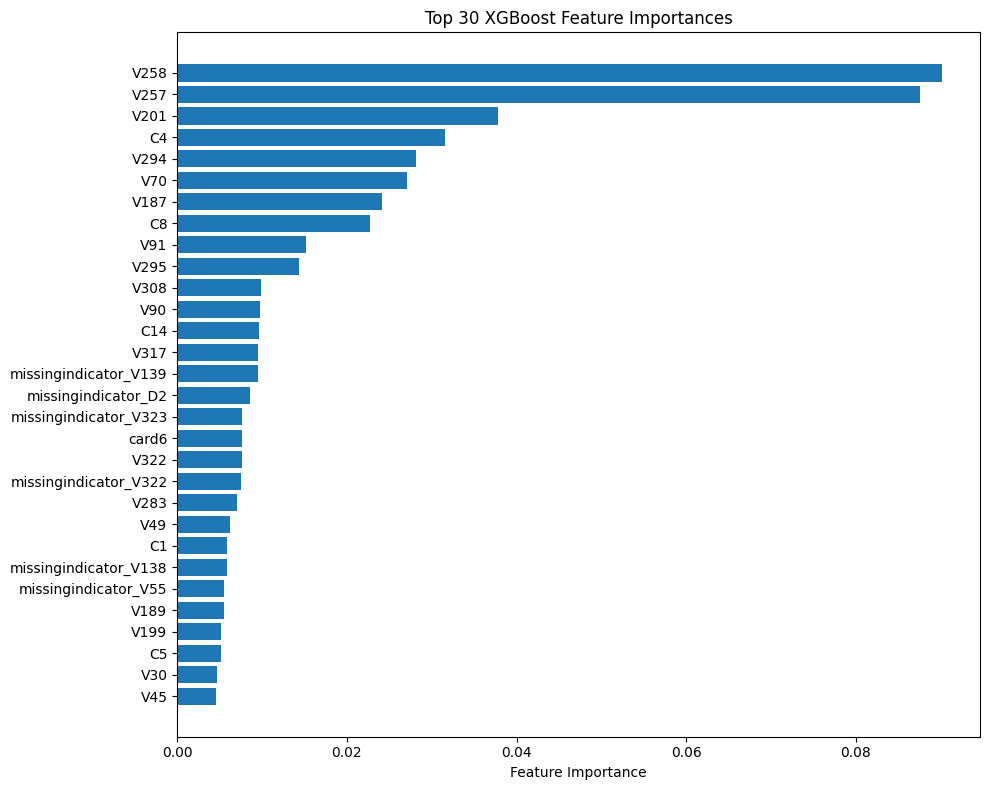

In [ ]:
import matplotlib.pyplot as plt

top_n = 30
top_importance = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
importance_df.to_csv("xgboost_feature_importance.csv", index=False)

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact("xgboost_feature_importance.csv")

# XGBoost with More Advanced Feature Engineering

In [15]:
X_train_transformed = preprocessing_pipeline_v2.transform(X_train)
X_valid_transformed = preprocessing_pipeline_v2.transform(X_test)

print(X_train_transformed.shape)
print(X_valid_transformed.shape)

(472432, 845)
(118108, 845)


In [19]:
inner_valid_size = int(len(y_train) * 0.2)
inner_split_idx = len(y_train) - inner_valid_size

X_inner_train_v2 = row_slice(X_train_transformed, 0, inner_split_idx)
y_inner_train_v2 = y_train.iloc[:inner_split_idx] if hasattr(y_train, "iloc") else y_train[:inner_split_idx]

X_inner_valid_v2 = row_slice(X_train_transformed, inner_split_idx, None)
y_inner_valid_v2 = y_train.iloc[inner_split_idx:] if hasattr(y_train, "iloc") else y_train[inner_split_idx:]

print(X_inner_train_v2.shape, X_inner_valid_v2.shape)
print(y_inner_train_v2.shape, y_inner_valid_v2.shape)

(377946, 845) (94486, 845)
(377946,) (94486,)


In [ ]:
# best 2 rows from old one
param_grid_v2 = [
    {
        "n_estimators": 1500,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "reg_lambda": 5.0,
        "reg_alpha": 0.5,
        "scale_pos_weight": scale_pos_weight_sqrt,
    },
    {
        "n_estimators": 1500,
        "learning_rate": 0.03,
        "max_depth": 5,
        "min_child_weight": 10,
        "subsample": 0.85,
        "colsample_bytree": 0.8,
        "reg_lambda": 2.0,
        "reg_alpha": 0.1,
        "scale_pos_weight": scale_pos_weight_sqrt,
    },
]

# random tuning
def sample_xgb_params():
    return {
        "n_estimators": random.choice([1200, 1500, 1800, 2200]),
        "learning_rate": random.choice([0.015, 0.02, 0.03, 0.04, 0.05]),
        "max_depth": random.choice([4, 5, 6, 7]),
        "min_child_weight": random.choice([5, 10, 15, 20, 30, 40]),
        "subsample": random.choice([0.75, 0.8, 0.85, 0.9]),
        "colsample_bytree": random.choice([0.65, 0.7, 0.75, 0.8, 0.85]),
        "reg_lambda": random.choice([1.0, 2.0, 3.0, 5.0, 8.0, 10.0]),
        "reg_alpha": random.choice([0.0, 0.1, 0.3, 0.5, 1.0]),
        "scale_pos_weight": random.choice([
            1.0,
            scale_pos_weight_sqrt,
            scale_pos_weight_sqrt * 0.75,
            scale_pos_weight_sqrt * 1.25
        ]),
    }

import random

random.seed(42)
np.random.seed(42)

n_trials = 20
results = []

for params in param_grid_v2:
    run_name = (
        f"XGB_FE_V2_"
        f"depth{params['max_depth']}_"
        f"lr{params['learning_rate']}_"
        f"child{params['min_child_weight']}_"
        f"spw{params['scale_pos_weight']:.2f}"
    )

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_type", "XGBClassifier")
        mlflow.set_tag("training_stage", "early_stopping_holdout_screening")
        mlflow.set_tag("preprocessing_type", "FE_V2_Preprocessing")
        mlflow.set_tag("preprocessing_run_id", xgboost_fe_v2_preprocessing_run_id)
        mlflow.set_tag("cv_used", False)
        mlflow.set_tag("early_stopping_used", True)

        mlflow.log_params(params)
        mlflow.log_param("objective", "binary:logistic")
        mlflow.log_param("tree_method", "hist")
        mlflow.log_param("eval_metric", "auc")
        mlflow.log_param("early_stopping_rounds", 50)
        mlflow.log_param("main_metric", "holdout_roc_auc")

        model = XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist", # faster
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1
        )

        print(f"\nRunning {run_name}...")

        model.fit(
            X_inner_train,
            y_inner_train,
            eval_set=[(X_inner_valid, y_inner_valid)],
            verbose=False
        )

        valid_proba = model.predict_proba(X_valid_transformed)[:, 1]
        valid_preds = model.predict(X_valid_transformed)

        holdout_roc_auc = roc_auc_score(y_test, valid_proba)
        holdout_avg_precision = average_precision_score(y_test, valid_proba)
        holdout_log_loss = log_loss(y_test, valid_proba)
        holdout_f1 = f1_score(y_test, valid_preds, zero_division=0)
        holdout_precision = precision_score(y_test, valid_preds, zero_division=0)
        holdout_recall = recall_score(y_test, valid_preds, zero_division=0)

        mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
        mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
        mlflow.log_metric("holdout_log_loss", holdout_log_loss)
        mlflow.log_metric("holdout_f1", holdout_f1)
        mlflow.log_metric("holdout_precision", holdout_precision)
        mlflow.log_metric("holdout_recall", holdout_recall)

        if hasattr(model, "best_iteration") and model.best_iteration is not None:
            mlflow.log_metric("best_iteration", model.best_iteration)

        if hasattr(model, "best_score") and model.best_score is not None:
            mlflow.log_metric("best_score", float(model.best_score))

        model_path = f"{run_name}.joblib"
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        results.append({
            "run_name": run_name,
            "preprocessing": "baseline",
            **params,
            "holdout_roc_auc": holdout_roc_auc,
            "holdout_average_precision": holdout_avg_precision,
            "holdout_log_loss": holdout_log_loss,
            "holdout_f1": holdout_f1,
            "holdout_precision": holdout_precision,
            "holdout_recall": holdout_recall,
            "best_iteration": getattr(model, "best_iteration", None)
        })

        print(
            f"{run_name} | "
            f"AUC={holdout_roc_auc:.4f} | "
            f"AP={holdout_avg_precision:.4f} | "
            f"LogLoss={holdout_log_loss:.4f} | "
            f"F1={holdout_f1:.4f} | "
            f"Precision={holdout_precision:.4f} | "
            f"Recall={holdout_recall:.4f} | "
            f"BestIter={getattr(model, 'best_iteration', None)}"
        )

results_df = pd.DataFrame(results).sort_values("holdout_roc_auc", ascending=False)
results_df

In [44]:
best_row = results_df.iloc[0]

best_iteration = int(best_row["best_iteration"])
best_iteration

1199

In [ ]:
best_params = best_row[[
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
    "reg_alpha",
    "scale_pos_weight",
]].to_dict()


best_iter_tuned = 988
best_params_tuned = {'n_estimators': 2200,
 'learning_rate': 0.03,
 'max_depth': 6,
 'min_child_weight': 10,
 'subsample': 0.8,
 'colsample_bytree': 0.75,
 'reg_lambda': 1.0,
 'reg_alpha': 0.0,
 'scale_pos_weight': 6.550462004549034
}
best_params = best_params_tuned
best_iteration = best_iter_tuned

best_params["n_estimators"] = int(best_iteration) + 1
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_child_weight"] = int(best_params["min_child_weight"])
best_params["learning_rate"] = float(best_params["learning_rate"])
best_params["subsample"] = float(best_params["subsample"])
best_params["colsample_bytree"] = float(best_params["colsample_bytree"])
best_params["reg_lambda"] = float(best_params["reg_lambda"])
best_params["reg_alpha"] = float(best_params["reg_alpha"])
best_params["scale_pos_weight"] = float(best_params["scale_pos_weight"])

best_params

{'n_estimators': 989,
 'learning_rate': 0.03,
 'max_depth': 6,
 'min_child_weight': 10,
 'subsample': 0.8,
 'colsample_bytree': 0.75,
 'reg_lambda': 1.0,
 'reg_alpha': 0.0,
 'scale_pos_weight': 6.550462004549034}

In [22]:
from sklearn.base import clone
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

best_model = XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_pipeline = Pipeline([
    ("preprocessing", clone(preprocessing_pipeline_v2)),
    ("model", best_model)
])

with mlflow.start_run(run_name="XGBoost_FE_V2_Final_FullPipeline_Tuned"):
    mlflow.set_tag("model_type", "XGBClassifier")
    mlflow.set_tag("training_stage", "final_full_pipeline")
    mlflow.set_tag("preprocessing_type", "FE_V2_Preprocessing")
    mlflow.set_tag("main_metric", "holdout_roc_auc")
    mlflow.set_tag("early_stopping_note", "n_estimators set from best_iteration during screening while random tuning")

    mlflow.log_params(best_params)

    print("Fitting final full pipeline...")
    final_pipeline.fit(X_train, y_train)

    print("Generating train predictions...")
    train_proba = final_pipeline.predict_proba(X_train)[:, 1]
    train_preds = final_pipeline.predict(X_train)

    print("Generating holdout predictions...")
    holdout_proba = final_pipeline.predict_proba(X_test)[:, 1]
    holdout_preds = final_pipeline.predict(X_test)

    train_roc_auc = roc_auc_score(y_train, train_proba)
    train_avg_precision = average_precision_score(y_train, train_proba)
    train_log_loss = log_loss(y_train, train_proba)
    train_f1 = f1_score(y_train, train_preds, zero_division=0)
    train_precision = precision_score(y_train, train_preds, zero_division=0)
    train_recall = recall_score(y_train, train_preds, zero_division=0)

    holdout_roc_auc = roc_auc_score(y_test, holdout_proba)
    holdout_avg_precision = average_precision_score(y_test, holdout_proba)
    holdout_log_loss = log_loss(y_test, holdout_proba)
    holdout_f1 = f1_score(y_test, holdout_preds, zero_division=0)
    holdout_precision = precision_score(y_test, holdout_preds, zero_division=0)
    holdout_recall = recall_score(y_test, holdout_preds, zero_division=0)

    roc_auc_gap = train_roc_auc - holdout_roc_auc
    average_precision_gap = train_avg_precision - holdout_avg_precision
    log_loss_gap = holdout_log_loss - train_log_loss
    f1_gap = train_f1 - holdout_f1
    precision_gap = train_precision - holdout_precision
    recall_gap = train_recall - holdout_recall

    mlflow.log_metric("train_roc_auc", train_roc_auc)
    mlflow.log_metric("train_average_precision", train_avg_precision)
    mlflow.log_metric("train_log_loss", train_log_loss)
    mlflow.log_metric("train_f1", train_f1)
    mlflow.log_metric("train_precision", train_precision)
    mlflow.log_metric("train_recall", train_recall)

    mlflow.log_metric("holdout_roc_auc", holdout_roc_auc)
    mlflow.log_metric("holdout_average_precision", holdout_avg_precision)
    mlflow.log_metric("holdout_log_loss", holdout_log_loss)
    mlflow.log_metric("holdout_f1", holdout_f1)
    mlflow.log_metric("holdout_precision", holdout_precision)
    mlflow.log_metric("holdout_recall", holdout_recall)

    mlflow.log_metric("roc_auc_gap", roc_auc_gap)
    mlflow.log_metric("average_precision_gap", average_precision_gap)
    mlflow.log_metric("log_loss_gap", log_loss_gap)
    mlflow.log_metric("f1_gap", f1_gap)
    mlflow.log_metric("precision_gap", precision_gap)
    mlflow.log_metric("recall_gap", recall_gap)

    model_path = "xgboost_fe_v2_final_full_pipeline.joblib"
    joblib.dump(final_pipeline, model_path)
    mlflow.log_artifact(model_path)

    print("\nFinal XGBoost Full Pipeline Results")
    print("-" * 60)

    print("\nTrain Metrics")
    print(f"ROC-AUC:           {train_roc_auc:.4f}")
    print(f"Average Precision: {train_avg_precision:.4f}")
    print(f"Log Loss:          {train_log_loss:.4f}")
    print(f"F1 Score:          {train_f1:.4f}")
    print(f"Precision:         {train_precision:.4f}")
    print(f"Recall:            {train_recall:.4f}")

    print("\nHoldout Metrics")
    print(f"ROC-AUC:           {holdout_roc_auc:.4f}")
    print(f"Average Precision: {holdout_avg_precision:.4f}")
    print(f"Log Loss:          {holdout_log_loss:.4f}")
    print(f"F1 Score:          {holdout_f1:.4f}")
    print(f"Precision:         {holdout_precision:.4f}")
    print(f"Recall:            {holdout_recall:.4f}")

    print("\nGeneralization Gaps")
    print(f"ROC-AUC Gap:           {roc_auc_gap:.4f}")
    print(f"Average Precision Gap: {average_precision_gap:.4f}")
    print(f"Log Loss Gap:          {log_loss_gap:.4f}")
    print(f"F1 Gap:                {f1_gap:.4f}")
    print(f"Precision Gap:         {precision_gap:.4f}")
    print(f"Recall Gap:            {recall_gap:.4f}")

    print("\nHoldout Confusion Matrix:")
    print(confusion_matrix(y_test, holdout_preds))

    print("\nHoldout Classification Report:")
    print(classification_report(y_test, holdout_preds, zero_division=0))

    final_run_id = mlflow.active_run().info.run_id
    print(f"\nFinal run id: {final_run_id}")

Fitting final full pipeline...
[Near-zero variance] Removed 12 features
['C3', 'V107', 'V108', 'V111', 'V113', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V305']
Generating train predictions...
Generating holdout predictions...

Final XGBoost Full Pipeline Results
------------------------------------------------------------

Train Metrics
ROC-AUC:           0.9807
Average Precision: 0.8421
Log Loss:          0.0868
F1 Score:          0.7730
Precision:         0.7681
Recall:            0.7780

Holdout Metrics
ROC-AUC:           0.9244
Average Precision: 0.5731
Log Loss:          0.1200
F1 Score:          0.5397
Precision:         0.5280
Recall:            0.5519

Generalization Gaps
ROC-AUC Gap:           0.0563
Average Precision Gap: 0.2690
Log Loss Gap:          0.0332
F1 Gap:                0.2333
Precision Gap:         0.2401
Recall Gap:            0.2261

Holdout Confusion Matrix:
[[112039   2005]
 [  1821   2243]]

Holdout Classification Report:
              precision    rec

In [ ]:
preprocessing = final_pipeline.named_steps["preprocessing"]
xgb_model = final_pipeline.named_steps["model"]

before_preprocessor = Pipeline(preprocessing.steps[:-1])
X_before_preprocessor = before_preprocessor.transform(X_train.head(100))

input_features = X_before_preprocessor.columns.tolist()

tree_preprocessor = preprocessing.named_steps["preprocessor"]

try:
    feature_names = tree_preprocessor.get_feature_names_out(input_features)
except Exception:
    feature_names = [f"f{i}" for i in range(len(xgb_model.feature_importances_))]

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.head(30)

,feature,importance
0,V258,0.095423
1,V257,0.045762
2,V201,0.040646
3,V294,0.034558
4,C4,0.031571
5,V91,0.026050
6,V70,0.025893
7,missingindicator_V323,0.021704
8,C8,0.021294
9,V69,0.015728


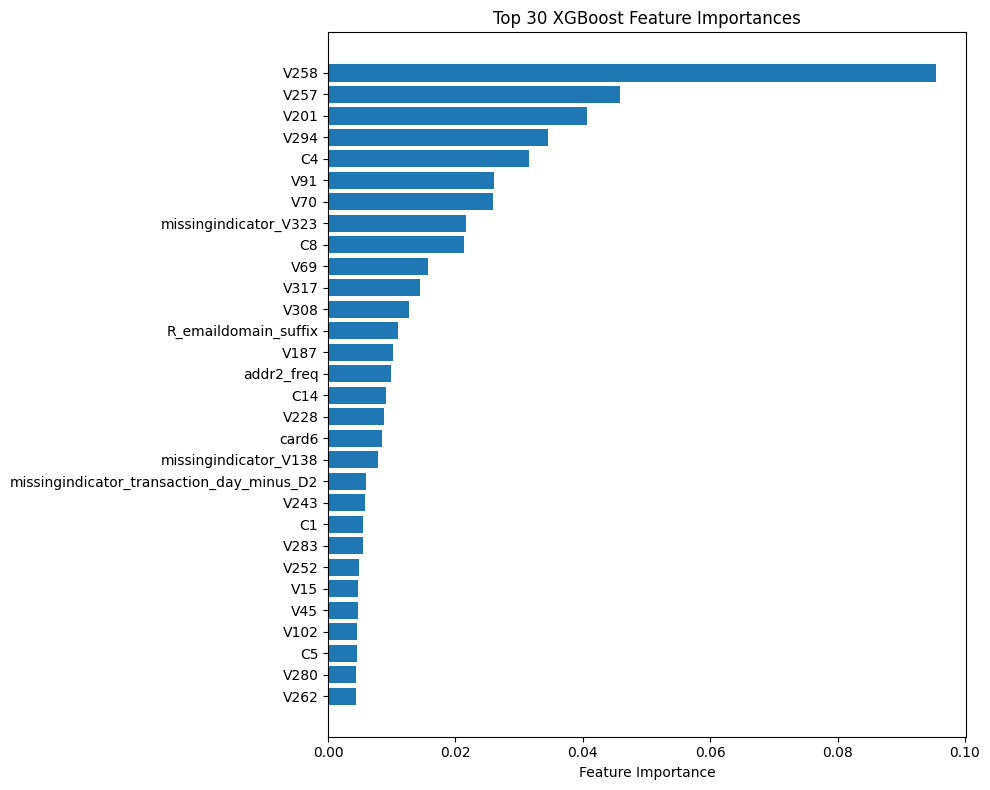

In [49]:
import matplotlib.pyplot as plt

top_n = 30
top_importance = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} XGBoost Feature Importances")
plt.tight_layout()
plt.show()

In [25]:
print(mlflow.search_runs(
    experiment_names=["XGBoost_Training"],
    order_by=["metrics.holdout_roc_auc DESC", "metrics.roc_auc_gap ASC", "metrics.holdout_log_loss ASC"]
)[['tags.mlflow.runName', 'metrics.train_roc_auc', 'metrics.roc_auc_gap', 'metrics.holdout_roc_auc', 'tags.preprocessing_type']].to_markdown(index=False))

| tags.mlflow.runName                        |   metrics.train_roc_auc |   metrics.roc_auc_gap |   metrics.holdout_roc_auc | tags.preprocessing_type   |
|:-------------------------------------------|------------------------:|----------------------:|--------------------------:|:--------------------------|
| XGBoost_FE_V2_Final_FullPipeline_Tuned     |                0.980714 |             0.0563119 |                  0.924402 | FE_V2_Preprocessing       |
| XGBoost_FE_V2_Final_FullPipeline           |                0.967138 |             0.0485837 |                  0.918555 | FE_V2_Preprocessing       |
| XGBoost_Final_FullPipeline                 |                0.955719 |             0.0447638 |                  0.910955 | Baseline_Preprocessing    |
| XGB_FE_V2_depth6_lr0.03_child10_spw6.55    |              nan        |           nan         |                  0.904689 | FE_V2_Preprocessing       |
| XGB_FE_V2_depth6_lr0.03_child10_spw5.24    |              nan        |          

In [47]:
xgb_runs = mlflow.search_runs(
    experiment_names=["XGBoost_Training"],
    #filter_string="tags.preprocessing_type='FE_V2_Preprocessing'", #FE_V2_Preprocessing #Baseline_Preprocessing
    order_by=["metrics.holdout_roc_auc DESC", "metrics.holdout_average_precision DESC", "metrics.holdout_log_loss ASC"]
    
)

cols = [
    "tags.mlflow.runName",
    "tags.preprocessing_type",
    "tags.training_stage",
    "metrics.holdout_roc_auc",
    "metrics.holdout_average_precision",
    "metrics.holdout_log_loss",
    "metrics.holdout_f1",
    "metrics.holdout_precision",
    "metrics.holdout_recall",
    "metrics.train_roc_auc",
    "metrics.roc_auc_gap",
    "metrics.average_precision_gap",
    "metrics.log_loss_gap",
    "params.n_estimators",
    "params.learning_rate",
    "params.max_depth",
    "params.min_child_weight",
    "params.subsample",
    "params.colsample_bytree",
    "params.reg_lambda",
    "params.reg_alpha",
    "params.scale_pos_weight",
]

available_cols = [col for col in cols if col in xgb_runs.columns]

xgb_df = xgb_runs[available_cols].copy()

xgb_df = xgb_df.rename(columns={
    "tags.mlflow.runName": "run_name",
    "tags.preprocessing_type": "preprocessing",
    "tags.training_stage": "training_stage",
    "metrics.holdout_roc_auc": "holdout_auc",
    "metrics.holdout_average_precision": "holdout_ap",
    "metrics.holdout_log_loss": "holdout_log_loss",
    "metrics.holdout_f1": "holdout_f1",
    "metrics.holdout_precision": "holdout_precision",
    "metrics.holdout_recall": "holdout_recall",
    "metrics.train_roc_auc": "train_auc",
    "metrics.roc_auc_gap": "auc_gap",
    "metrics.average_precision_gap": "ap_gap",
    "metrics.log_loss_gap": "log_loss_gap",
})

xgb_df = xgb_df.sort_values("holdout_auc", ascending=False).reset_index(drop=True)

print(
    xgb_df[[
        "run_name",
        #"preprocessing",
        #"training_stage",
        "holdout_auc",
        "holdout_ap",
        "holdout_log_loss",
        "holdout_f1",
        "holdout_precision",
        "holdout_recall",
        "auc_gap"
    ]]
    .head(20)
    .to_markdown(index=False)
)

| run_name                                   |   holdout_auc |   holdout_ap |   holdout_log_loss |   holdout_f1 |   holdout_precision |   holdout_recall |     auc_gap |
|:-------------------------------------------|--------------:|-------------:|-------------------:|-------------:|--------------------:|-----------------:|------------:|
| XGBoost_FE_V2_Final_FullPipeline_Tuned     |      0.924402 |     0.573057 |          0.120048  |     0.539702 |            0.528013 |         0.551919 |   0.0563119 |
| XGBoost_FE_V2_Final_FullPipeline           |      0.918555 |     0.549461 |          0.121532  |     0.524518 |            0.520077 |         0.529035 |   0.0485837 |
| XGBoost_Final_FullPipeline                 |      0.910955 |     0.532247 |          0.127728  |     0.504498 |            0.498558 |         0.510581 |   0.0447638 |
| XGB_FE_V2_depth6_lr0.03_child10_spw6.55    |      0.904689 |     0.504395 |          0.139654  |     0.47545  |            0.438331 |         0.519439 | 